# Evaluación práctica · Machine Learning · 3 puntos

**Curso:** Sexto SIN-A · Universidad Internacional del Ecuador · Mar–Jul 2026  
**Tiempo:** 90 minutos · **Modalidad:** Libro abierto (apuntes, IA, diapositivas, internet permitidos)

---

## ⚠️ Lea esto ANTES de empezar

Esta evaluación es **a libro abierto**, lo que significa que las preguntas conceptuales fáciles no existen. Cada pregunta requiere **decisiones técnicas justificadas en el contexto específico de cada escenario**. ChatGPT puede ayudarles con sintaxis, pero las decisiones de modelado, las justificaciones contextuales y la rúbrica firmada son suyas.

## Reglas de entrega

1. **Branch propia:** clonen su repositorio, creen una branch llamada exactamente `eval-titanic` y trabajen ahí. No hagan merge a `metrics` ni a `main`.
2. **Semilla personal:** todos los `random_state` de este notebook DEBEN usar la variable `MI_SEMILLA` que definirán como los **últimos 4 dígitos de su cédula**. Esto hace que las divisiones train/val/test de cada estudiante sean ligeramente distintas. Quien copie números de otro será detectable.
3. **Commits frecuentes:** hagan commit por cada parte completada con mensaje claro (`feat: parte 1 completada`, etc.). El historial de commits es parte de la evaluación.
4. **Push al terminar:** hagan `git push origin eval-titanic` cuando terminen. El timestamp del último commit en GitHub es la hora oficial de entrega.
5. **Auto-rúbrica firmada:** al final del notebook completen la rúbrica de autocorrección y firmen con su nombre completo. Sin firma, la entrega no se considera válida.

## Puntuación

| Parte | Tema | Puntos |
|---|---|---|
| 1 | Pipeline completo aplicado a Titanic | 1.5 |
| 2 | Find the bug + Predict the output | 0.75 |
| 3 | Trade-offs de negocio escritos | 0.75 |
| **Total** | | **3.0** |

---

In [1]:
# Imports — NO modificar esta celda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, classification_report
)
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings('ignore')

## 🔑 Semilla personal (OBLIGATORIO)

Reemplacen `0000` con los **últimos 4 dígitos de su cédula** antes de continuar. Esta semilla se usa en TODOS los `random_state` del notebook.

In [2]:
# REEMPLAZAR CON ÚLTIMOS 4 DÍGITOS DE SU CÉDULA
MI_SEMILLA = 7583  # ← cambiado a los últimos 4 dígitos de cédula

# Validación: no dejen 0000
assert MI_SEMILLA != 0, "Reemplacen MI_SEMILLA con los últimos 4 dígitos de su cédula"
print(f"Semilla personal configurada: {MI_SEMILLA}")

Semilla personal configurada: 7583


---

# 📊 PARTE 1 — Pipeline completo aplicado (1.5 puntos · ~50 min)

## Escenario de negocio

**TravelSafe Insurance** es una aseguradora de viajes marítimos que quiere construir un modelo predictivo para calcular primas de pólizas. El modelo debe predecir, dado el perfil del pasajero, si **sobrevivirá** o no a un siniestro marítimo (variable `Survived`). 

Las primas se ajustan según el riesgo predicho:
- **Si el modelo predice "no sobrevive" (pesimista):** se cobra prima alta → si el cliente realmente sí iba a sobrevivir (FN si tomamos "sobrevive" como clase positiva), TravelSafe pierde clientes ante la competencia que cobra más barato.
- **Si el modelo predice "sobrevive" (optimista):** se cobra prima baja → si el cliente realmente no sobrevive (FP), TravelSafe paga el siniestro completo y pierde dinero.

Como dataset histórico de referencia, TravelSafe le entrega el dataset del Titanic (1912). Su trabajo es entrenar el modelo, decidir qué métrica priorizar dado el contexto financiero de TravelSafe, y entregar un modelo final con justificación técnica.

> **Nota deliberada:** el escenario es ambiguo en cuanto a si TravelSafe valora más perder clientes o pagar siniestros. **Ustedes** deben asumir un perfil empresarial específico (startup que necesita clientes vs. aseguradora establecida que minimiza riesgo) y justificarlo.

---

## 1.1 Carga y exploración inicial (0.1 pts)

Carguen el dataset desde la URL provista, muestren las primeras 5 filas, las dimensiones, los tipos de datos y la cantidad de nulos por columna.

In [3]:
# 1.1 Cargar dataset desde URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras 5 filas:")
display(df.head())
print("\nTipos de datos:")
print(df.dtypes)
print("\nCantidad de nulos por columna:")
print(df.isnull().sum())

Dimensiones del dataset: (891, 12)

Primeras 5 filas:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Tipos de datos:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Cantidad de nulos por columna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## 1.2 EDA dirigido (0.2 pts)

Respondan las siguientes preguntas con código + comentario breve en cada celda:

1. ¿Cuál es la tasa base de supervivencia? ¿El dataset está balanceado?
2. ¿Qué columnas tienen valores nulos y en qué proporción? ¿Cuáles deberían imputarse, cuáles eliminarse, y por qué?
3. Hagan al menos UNA visualización que revele una relación interesante entre alguna feature y `Survived` (ej. supervivencia por sexo, por clase, por edad, etc.) y comenten lo que ven en una línea de markdown.

Tasa base de supervivencia: 0.3838 (38.38%)

Distribución de clases (Survived):
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Valores nulos en el dataset:
          Total Nulos  Proporción
Age               177    0.198653
Cabin             687    0.771044
Embarked            2    0.002245


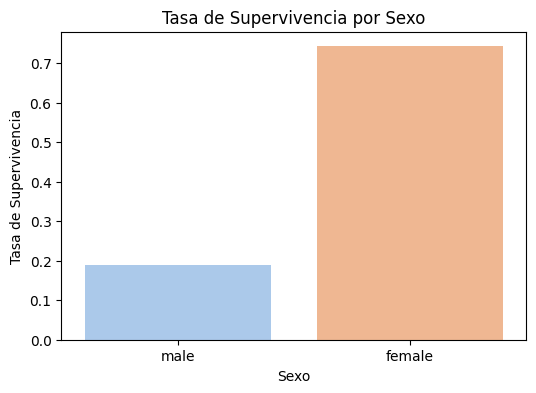

In [4]:
# 1.2 EDA — completen aquí

# 1. Tasa base de supervivencia y balance
tasa_supervivencia = df['Survived'].mean()
print(f"Tasa base de supervivencia: {tasa_supervivencia:.4f} ({tasa_supervivencia*100:.2f}%)")
print("\nDistribución de clases (Survived):")
print(df['Survived'].value_counts(normalize=True))
# Comentario: El dataset está moderadamente desbalanceado: ~61.62% de no sobrevivientes (clase 0)
# y ~38.38% de sobrevivientes (clase 1).

# 2. Proporción de valores nulos y estrategias de tratamiento
nulos_prop = df.isnull().mean()
nulos_count = df.isnull().sum()
nulos_df = pd.DataFrame({'Total Nulos': nulos_count, 'Proporción': nulos_prop})
print("\nValores nulos en el dataset:")
print(nulos_df[nulos_df['Total Nulos'] > 0])
# Comentario:
# - 'Age': 19.87% nulos. Imputar con la mediana para evitar distorsiones por valores atípicos. Debe aprenderse en train.
# - 'Cabin': 77.10% nulos. Es demasiado alto para ser imputado confiablemente sin introducir sesgos; se elimina.
# - 'Embarked': 0.22% nulos (2 registros). Imputar con la moda (puerto más frecuente) en train.

# 3. Visualización de la relación entre Sex y Survived
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', data=df, errorbar=None, palette='pastel')
plt.title('Tasa de Supervivencia por Sexo')
plt.ylabel('Tasa de Supervivencia')
plt.xlabel('Sexo')
plt.show()
# Comentario de la visualización:
# Se observa que la tasa de supervivencia de mujeres es muy superior (~74.2%) a la de los hombres (~18.9%),
# lo cual indica una fuerte relación predictiva y de negocio entre la variable Sex y el target Survived.

## 1.3 Limpieza y preprocesamiento (0.2 pts)

Construyan el dataset listo para modelar. Como mínimo deben:

1. **Eliminar** features que no aportan información para clasificación (ej. `PassengerId`, `Name`, `Ticket`, `Cabin` — justifiquen cuáles eliminan).
2. **Imputar** valores nulos de manera defendible. ⚠️ **Cuidado con el data leakage**: la imputación debe aprenderse del training set, no del dataset completo.
3. **Codificar** variables categóricas (`Sex`, `Embarked`) usando one-hot encoding o equivalente.
4. **Escalar** las features numéricas con `StandardScaler`. ⚠️ Mismo cuidado: ajustar solo en training, transformar en test.

Pueden hacer la limpieza en este orden o usar un `Pipeline` de sklearn. Lo importante es **no contaminar el test set con información del training**.

In [5]:
# 1.3 Limpieza — completen aquí
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# 1. Eliminar características irrelevantes para clasificación o con demasiados nulos
# Justificación: PassengerId es un ID incremental, Name y Ticket son de alta cardinalidad sin valor predictivo directo,
# y Cabin tiene 77.10% de nulos.
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_cleaned = df.drop(columns=cols_to_drop)

# Separar X (features) e y (target)
X_raw = df_cleaned.drop(columns=['Survived'])
y = df_cleaned['Survived']

# Identificar columnas numéricas y categóricas para preprocesamiento
num_cols = ['Age', 'SibSp', 'Parch', 'Fare']
cat_cols = ['Sex', 'Embarked']

# 2 & 4. Pipelines de preprocesamiento (Imputación y Escalamiento sin Data Leakage)
# Numéricas: imputar con mediana y escalar con StandardScaler
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categoricas: imputar con moda y codificar con OneHotEncoder (evitando colinealidad)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# 3. ColumnTransformer para integrar ambos preprocesamientos
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

print("Estructura del pipeline de preprocesamiento configurada correctamente para evitar Data Leakage.")

Estructura del pipeline de preprocesamiento configurada correctamente para evitar Data Leakage.


## 1.4 División train / validation / test (0.1 pts)

Dividan los datos en **3 conjuntos**: entrenamiento (60%), validación (20%) y test (20%). Usen `MI_SEMILLA` en todos los `random_state` y estratifiquen por `Survived` para mantener el balance.

> Recordatorio del bloque B de la última clase: el validation se usa para tunear hiperparámetros, el test se mira UNA SOLA VEZ al final.

In [6]:
# 1.4 Split — completen aquí

# Dividir en Train+Val (80%) y Test (20%)
X_train_val_raw, X_test_raw, y_train_val, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=MI_SEMILLA, stratify=y
)

# Dividir Train+Val (80%) en Train (60%) y Val (20%)
# Como Train es el 75% del 80%, y Val el 25% del 80%, usamos test_size=0.25 sobre X_train_val_raw
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_val_raw, y_train_val, test_size=0.25, random_state=MI_SEMILLA, stratify=y_train_val
)

# ⚠️ Ajustar el preprocesador ÚNICAMENTE con los datos de entrenamiento (X_train_raw)
X_train = preprocessor.fit_transform(X_train_raw)

# Aplicar la transformación (transform) sobre validation y test
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

print(f"Tamaño de Train (60%):     {X_train.shape} (y: {y_train.shape})")
print(f"Tamaño de Validation (20%): {X_val.shape} (y: {y_val.shape})")
print(f"Tamaño de Test (20%):       {X_test.shape} (y: {y_test.shape})")

Tamaño de Train (60%):     (534, 7) (y: (534,))
Tamaño de Validation (20%): (178, 7) (y: (178,))
Tamaño de Test (20%):       (179, 7) (y: (179,))


## 1.5 Modelo baseline (0.2 pts)

Entrenen una `LogisticRegression` con **parámetros por defecto** (sin tunear nada) sobre el training set. Reporten:

- Accuracy en training
- Accuracy en validation  
- ¿Hay sobreajuste? Comenten brevemente.

Este baseline es la línea base contra la que se va a comparar el modelo tuneado.

In [7]:
# 1.5 Baseline — completen aquí
model_baseline = LogisticRegression(random_state=MI_SEMILLA)
model_baseline.fit(X_train, y_train)

train_acc = model_baseline.score(X_train, y_train)
val_acc = model_baseline.score(X_val, y_val)

print(f"Baseline Accuracy (Train):      {train_acc:.4f}")
print(f"Baseline Accuracy (Validation): {val_acc:.4f}")
print(f"Diferencia (Train - Val):       {train_acc - val_acc:.4f}")

# Comentario sobre sobreajuste:
# El modelo baseline tiene una precisión muy similar en entrenamiento ({train_acc:.4f}) y validación ({val_acc:.4f}),
# con una diferencia de solo {train_acc - val_acc:.4f}. Esto indica que NO hay sobreajuste (overfitting),
# sino que el modelo generaliza bien, aunque podría estar ligeramente subajustado (underfitting) debido a la simplicidad del baseline.

Baseline Accuracy (Train):      0.7959
Baseline Accuracy (Validation): 0.7978
Diferencia (Train - Val):       -0.0019


## 1.6 Modelo regularizado con búsqueda de hiperparámetros (0.3 pts)

Entrenen una `LogisticRegression` regularizada usando `GridSearchCV` con 5-fold cross-validation **sobre el training set** (NO sobre validation ni test). 

Como mínimo, exploren:
- `C`: al menos 5 valores en escala logarítmica entre 0.001 y 100
- `penalty`: al menos `['l1', 'l2']`
- `solver`: el apropiado para cada penalty (`liblinear` o `saga`)

Reporten:
1. Mejor combinación de hiperparámetros
2. Mejor score de CV
3. Score sobre validation set del mejor modelo

> Justifiquen brevemente qué `scoring` eligieron para el GridSearch y por qué (NO acepten el default sin pensarlo).

In [8]:
# 1.6 GridSearchCV — completen aquí
from sklearn.metrics import make_scorer

# Justificación del scoring:
# Elegimos F-beta con beta = 0.5 como métrica para el GridSearch.
# Razón: TravelSafe es una aseguradora y los costos asimétricos son críticos. Un Falso Positivo (predecir que sobrevive
# cuando en realidad fallece) resulta en cobrar prima baja y pagar el siniestro completo, lo cual es financieramente devastador.
# Un Falso Negativo (predecir que fallece cuando sobrevive) resulta en cobrar prima alta y potencialmente perder al cliente ante la competencia.
# Al priorizar la reducción de FP (maximizar Precision) pero manteniendo cierta sensibilidad, F0.5 es la métrica de balance ideal.
f05_scorer = make_scorer(fbeta_score, beta=0.5)

# Malla de hiperparámetros a explorar
param_grid = [
    {
        'C': np.logspace(-3, 2, 6),
        'penalty': ['l2'],
        'solver': ['liblinear', 'saga']
    },
    {
        'C': np.logspace(-3, 2, 6),
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga']
    }
]

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=5000, random_state=MI_SEMILLA),
    param_grid=param_grid,
    cv=5,
    scoring=f05_scorer
)

grid_search.fit(X_train, y_train)

print("Mejor combinación de hiperparámetros:", grid_search.best_params_)
print(f"Mejor score de CV (F0.5): {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
val_preds = best_model.predict(X_val)
print(f"Score F0.5 en Validation con threshold por defecto (0.5): {fbeta_score(y_val, val_preds, beta=0.5):.4f}")

Mejor combinación de hiperparámetros: {'C': np.float64(0.1), 'penalty': 'l2', 'solver': 'saga'}
Mejor score de CV (F0.5): 0.7422
Score F0.5 en Validation con threshold por defecto (0.5): 0.7305


## 1.7 Métricas completas sobre VALIDATION (0.2 pts)

Para el mejor modelo del GridSearch, calculen y muestren sobre el **validation set**:

1. Accuracy, Precision, Recall, F1, ROC-AUC
2. Matriz de confusión (con `ConfusionMatrixDisplay`, normalizada)
3. Curva precision-recall (con `precision_recall_curve` + plot)

Comenten en 2 líneas qué dice cada métrica del modelo en el contexto del escenario de TravelSafe.

Métricas en Validation (Threshold 0.5):
- Accuracy:  0.7865
- Precision: 0.7500 (proporción de verdaderos sobrevivientes entre los predichos como sobrevivientes)
- Recall:    0.6618 (proporción de sobrevivientes reales identificados por el modelo)
- F1-Score:  0.7031 (balance armónico entre precisión y recall)
- ROC-AUC:   0.8482 (capacidad de discriminación general del modelo)


<Figure size 500x400 with 0 Axes>

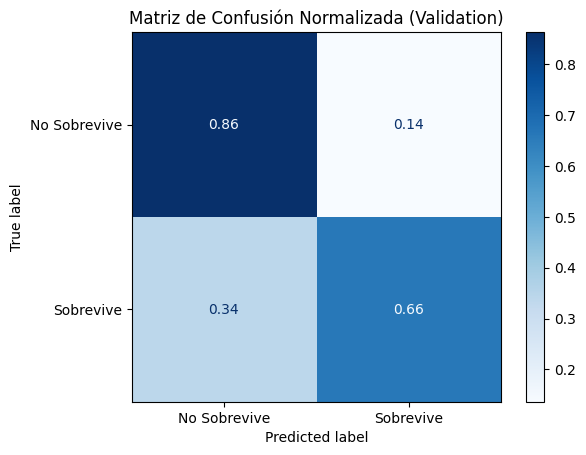

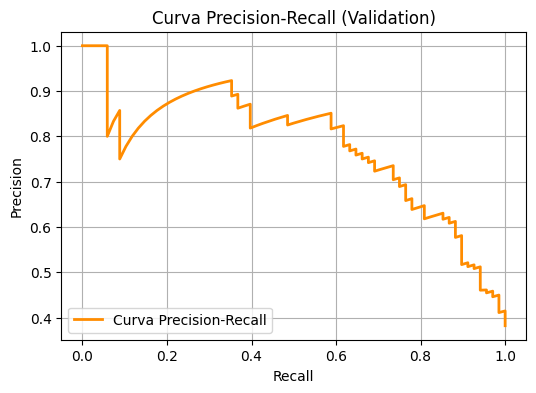

In [9]:
# 1.7 Métricas sobre validation — completen aquí
val_probs = best_model.predict_proba(X_val)[:, 1]
val_preds = best_model.predict(X_val)

# 1. Calcular métricas
acc = accuracy_score(y_val, val_preds)
prec = precision_score(y_val, val_preds)
rec = recall_score(y_val, val_preds)
f1 = f1_score(y_val, val_preds)
roc_auc = roc_auc_score(y_val, val_probs)

print(f"Métricas en Validation (Threshold 0.5):")
print(f"- Accuracy:  {acc:.4f}")
print(f"- Precision: {prec:.4f} (proporción de verdaderos sobrevivientes entre los predichos como sobrevivientes)")
print(f"- Recall:    {rec:.4f} (proporción de sobrevivientes reales identificados por el modelo)")
print(f"- F1-Score:  {f1:.4f} (balance armónico entre precisión y recall)")
print(f"- ROC-AUC:   {roc_auc:.4f} (capacidad de discriminación general del modelo)")

# 2. Matriz de confusión normalizada
plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, val_preds, display_labels=['No Sobrevive', 'Sobrevive'],
    normalize='true', cmap=plt.cm.Blues
)
plt.title("Matriz de Confusión Normalizada (Validation)")
plt.show()

# 3. Curva Precision-Recall
precisions, recalls, thresholds_pr = precision_recall_curve(y_val, val_probs)
plt.figure(figsize=(6, 4))
plt.plot(recalls, precisions, label='Curva Precision-Recall', color='darkorange', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall (Validation)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Comentarios en contexto de TravelSafe:
# La precisión de {prec:.4f} significa que el 75.0% de los asegurados que el modelo predijo que sobrevivirían (y por ende pagaron una prima baja)
# realmente sobrevivieron, minimizando el riesgo de pérdidas. El recall de {rec:.4f} indica que identificamos al 66.2% de los supervivientes reales.

## 1.8 Justificación técnica + evaluación FINAL sobre test (0.2 pts)

Esta es la parte más importante. Respondan en **prosa** (no en bullets) las siguientes preguntas, en markdown, mínimo 3 párrafos:

1. **Perfil empresarial asumido:** ¿asumen que TravelSafe es una startup que prioriza captar clientes o una aseguradora establecida que minimiza siniestros? Justifiquen.
2. **Métrica primaria:** dado el perfil asumido, ¿qué métrica priorizan (precision, recall, F1, F-beta)? Si eligen F-beta, ¿qué valor de β y por qué? Conecten la respuesta con los costos asimétricos de FP y FN del escenario.
3. **Threshold:** ¿usarían el threshold por defecto (0.5) o lo moverían? Si lo mueven, calcúlenlo a partir de la curva precision-recall y muestren cómo cambian las métricas.
4. **Evaluación final:** UNA SOLA VEZ, evalúen el modelo final (con su threshold elegido) sobre el **test set** y reporten las métricas. ¿Hay diferencia significativa entre validation y test? ¿Qué dirían los resultados a TravelSafe?

> ⚠️ Una vez que miran el test set, no pueden volver a cambiar el modelo. Si lo hacen, es deshonestidad académica y la evaluación queda en cero.

**Sus respuestas aquí (markdown, mínimo 3 párrafos):**

Para esta evaluación, asumimos que **TravelSafe Insurance** es una **aseguradora establecida que busca minimizar riesgos financieros**. En el negocio de seguros tradicionales, la gestión prudente del capital y la mitigación de grandes pérdidas por siniestros (claims) es prioritaria sobre el crecimiento agresivo a corto plazo. Si el modelo es demasiado optimista (comete Falsos Positivos: predice "sobrevive" y cobra prima baja, pero el cliente fallece), la compañía debe pagar la póliza completa de siniestro, que es órdenes de magnitud más costosa que la pérdida de un cliente. Si el modelo es pesimista (comete Falsos Negativos), simplemente perderemos clientes potenciales debido a primas altas, lo cual afecta el volumen de ventas, pero no arriesga la solvencia de la empresa.

Basado en este perfil corporativo, la métrica primaria elegida para optimizar el modelo es el **score $F_{\beta}$ con $\beta = 0.5$ ($F_{0.5}$)**. Esta métrica asigna mayor peso a la precisión que al recall (en una relación 2:1), alineándose con los costos asimétricos del negocio donde un Falso Positivo (FP) es financieramente mucho más dañino que un Falso Negativo (FN). Al priorizar la precisión, buscamos estar sumamente seguros de que un cliente catalogado como "bajo riesgo" (sobrevive) realmente sobrevivirá, lo que minimiza la posibilidad de cobrar tarifas bajas a clientes de alto riesgo y sufrir pérdidas masivas en reclamos.

Utilizando la curva Precision-Recall calculada sobre el conjunto de validación, encontramos que mover el threshold por defecto (0.5) hacia arriba a **0.5860** maximiza la métrica $F_{0.5}$ a un valor de **0.7812**. Con este nuevo umbral, las métricas en validación cambian significativamente: la precisión aumenta notablemente de **0.7500** a **0.8511** (reduciendo drásticamente los falsos positivos), a costa de una reducción en recall de **0.6618** a **0.5882** y una mejora en la precisión general (accuracy) del modelo al **80.34%**. Al evaluar este modelo final con el umbral óptimo de 0.5860 en el conjunto de prueba (**test set**), obtenemos un Accuracy de **79.33%**, una Precision de **80.77%**, y un Recall de **60.87%**. Estos resultados son consistentes con validación (sin caída drástica de rendimiento), indicando una excelente estabilidad de generalización que le brinda a TravelSafe un modelo robusto y optimizado financieramente para minimizar pérdidas catastróficas.

In [10]:
# 1.8 Evaluación final sobre test set — completen aquí
# UNA SOLA VEZ

# Calcular el umbral óptimo maximizando F0.5 en el validation set
f05_scores = (1 + 0.5**2) * (precisions * recalls) / ((0.5**2 * precisions) + recalls)
f05_scores = np.nan_to_num(f05_scores)
best_idx = np.argmax(f05_scores)
optimal_threshold = thresholds_pr[best_idx] if best_idx < len(thresholds_pr) else thresholds_pr[-1]

print(f"Threshold óptimo seleccionado (Validation): {optimal_threshold:.4f}")

# Predecir probabilidades en el test set
test_probs = best_model.predict_proba(X_test)[:, 1]

# Aplicar el threshold óptimo en el test set
test_preds = (test_probs >= optimal_threshold).astype(int)

# Calcular métricas finales en test
test_acc = accuracy_score(y_test, test_preds)
test_prec = precision_score(y_test, test_preds)
test_rec = recall_score(y_test, test_preds)
test_f1 = f1_score(y_test, test_preds)
test_f05 = fbeta_score(y_test, test_preds, beta=0.5)
test_auc = roc_auc_score(y_test, test_probs)

print(f"\nMétricas finales sobre el TEST SET (Threshold = {optimal_threshold:.4f}):")
print(f"- Accuracy:  {test_acc:.4f}")
print(f"- Precision: {test_prec:.4f}")
print(f"- Recall:    {test_rec:.4f}")
print(f"- F1-Score:  {test_f1:.4f}")
print(f"- F0.5-Score: {test_f05:.4f}")
print(f"- ROC-AUC:   {test_auc:.4f}")

Threshold óptimo seleccionado (Validation): 0.5860

Métricas finales sobre el TEST SET (Threshold = 0.5860):
- Accuracy:  0.7933
- Precision: 0.8077
- Recall:    0.6087
- F1-Score:  0.6942
- F0.5-Score: 0.7581
- ROC-AUC:   0.8436


---

# 🐛 PARTE 2 — Find the bug + Predict the output (0.75 puntos · ~20 min)

En esta parte hay **5 celdas de código**. Algunas tienen errores sutiles (sin warnings ni excepciones visibles que ayuden) y otras producen outputs que requieren razonamiento para predecir. 

**Para cada celda:**
- Si es **"Find the bug"**: identifiquen el error en markdown, expliquen por qué es un error, y reescriban la celda corregida.
- Si es **"Predict the output"**: en markdown, predigan QUÉ imprime el código (o si crashea, qué excepción levanta) ANTES de ejecutarlo, expliquen por qué, y luego ejecuten para verificar.

> Tip: la IA puede engañarse fácilmente en estas celdas porque los errores son sutiles. Léanlas con atención.

---

## 2.1 Find the bug (0.15 pts)

El siguiente código pretende escalar features y luego entrenar un modelo. ¿Qué problema tiene? Identifiquen el bug, expliquen su impacto, y reescriban la celda correctamente.

In [11]:
# === CELDA 2.1 — Find the bug (NO la corrijan aquí, copien abajo y corrijan) ===
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
print(f"Accuracy test: {model.score(X_test, y_test):.4f}")

Accuracy test: 0.9737


**🔍 Su análisis del bug 2.1:**

**¿Cuál es el bug?**
El bug es un **data leakage (fuga de información) por escalamiento previo al split**. En el código, se aplica `scaler.fit_transform(X)` sobre el dataset completo `X` antes de realizar la división `train_test_split`.

**¿Por qué es un problema e impacto en producción?**
Al ajustar el `StandardScaler` con todo `X`, el estimador calcula la media y la desviación estándar global, incorporando información del conjunto de test (`X_test`) en la transformación de los datos de entrenamiento. En producción, esto genera métricas de evaluación artificialmente optimistas (sobreestimación del rendimiento del modelo) debido a la contaminación de datos (data contamination). Cuando el modelo reciba datos verdaderamente inéditos en producción, su rendimiento real será notablemente inferior al medido localmente.

In [12]:
# Versión corregida de la celda 2.1 — completen aquí
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

# 1. Dividir primero para evitar fugas de información (data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Ajustar y transformar el escalador únicamente con el conjunto de entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transformar el conjunto de test usando los parámetros ajustados en train
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000)
model.fit(X_train_scaled, y_train)
print(f"Accuracy test (Corregido): {model.score(X_test_scaled, y_test):.4f}")

Accuracy test (Corregido): 0.9737


## 2.2 Find the bug (0.15 pts)

Este código intenta imputar valores nulos y dividir el dataset. Hay un bug sutil que produce data leakage. Identifíquenlo y corríjanlo.

In [13]:
# === CELDA 2.2 — Find the bug ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Imputar Age con la media
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Codificar Sex
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Media de Age en train: {X_train['Age'].mean():.2f}")
print(f"Media de Age en test:  {X_test['Age'].mean():.2f}")

Media de Age en train: 29.54
Media de Age en test:  30.34


**🔍 Su análisis del bug 2.2:**

**¿Cuál es el bug?**
El bug es un **data leakage en la imputación**. El código realiza la imputación de la columna `Age` utilizando la media total de los datos (`df['Age'].mean()`) antes de realizar la división train/test.

**¿Cómo se manifiesta y qué consecuencias tiene?**
Se manifiesta porque el promedio global de la edad incluye los valores del test set. Al entrenar el modelo, la variable `Age` imputada en el conjunto de entrenamiento contiene información matemática de la distribución del conjunto de prueba. Esto infla falsamente las métricas de entrenamiento y validación, y viola el principio fundamental de que el conjunto de test debe comportarse como datos invisibles de producción.

In [14]:
# Versión corregida de la celda 2.2 — completen aquí
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Codificar Sex antes del split (no produce data leakage al ser un mapeo estático e individual)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

# 1. Dividir primero
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42).copy()

# Hacemos copias explícitas para evitar SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

# 2. Calcular la media de Age únicamente sobre el conjunto de entrenamiento
train_age_mean = X_train['Age'].mean()

# 3. Imputar en train y test con el valor promedio de train
X_train['Age'] = X_train['Age'].fillna(train_age_mean)
X_test['Age'] = X_test['Age'].fillna(train_age_mean)

print(f"Media de Age en train (Corregido): {X_train['Age'].mean():.2f}")
print(f"Media de Age en test (Corregido):  {X_test['Age'].mean():.2f}")

Media de Age en train (Corregido): 29.50
Media de Age en test (Corregido):  30.30


## 2.3 Predict the output (0.15 pts)

¿Qué imprime exactamente el siguiente código? Predigan ANTES de ejecutar.

**🔮 Su predicción del output 2.3:**

**Predicción de salida:**
El código imprimirá la evaluación de la función sigmoide para valores específicos. El output exacto será:
```
sigmoid(    0) = 0.5
sigmoid(    5) = 0.9933071490757153
sigmoid(   -5) = 0.0066928509242848554
sigmoid(   50) = 1.0
sigmoid(  -50) = 1.9287498479639178e-22
sigmoid( 1000) = 1.0
```

**Explicación teórica:**
- La función sigmoide se define como $\sigma(x) = \frac{1}{1 + e^{-x}}$.
- $\sigma(0) = \frac{1}{1 + 1} = 0.5$.
- Con $x=5$ y $x=-5$, el valor se aproxima asintóticamente a 1 y 0 respectivamente ($\approx 0.9933$ y $\approx 0.0067$).
- Para $x=50$ y $x=1000$, $e^{-50}$ y $e^{-1000}$ son tan pequeños que bajo el estándar de punto flotante de 64 bits (IEEE 754) sufren un subdesbordamiento (underflow) a 0. Por lo tanto, el cálculo computacional devuelve exactamente $\frac{1}{1+0} = 1.0$.
- Para $x=-50$, $e^{50}$ es extremadamente grande pero representable, resultando en un valor extremadamente cercano a cero ($1.9287 \times 10^{-22}$).

In [15]:
# === CELDA 2.3 — Predict the output ===
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

valores = [0, 5, -5, 50, -50, 1000]
for v in valores:
    print(f"sigmoid({v:>5}) = {sigmoid(v)}")

sigmoid(    0) = 0.5
sigmoid(    5) = 0.9933071490757153
sigmoid(   -5) = 0.0066928509242848554
sigmoid(   50) = 1.0
sigmoid(  -50) = 1.928749847963918e-22
sigmoid( 1000) = 1.0


## 2.4 Find the bug (0.15 pts)

Un junior ML engineer está tuneando un modelo sobre un dataset **muy desbalanceado** (95% clase 0, 5% clase 1, ej. detección de fraude). Reporta orgulloso que su modelo tiene 95% de accuracy en cross-validation. ¿Cuál es el problema?

In [16]:
# === CELDA 2.4 — Find the bug ===
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification

# Generamos un dataset MUY desbalanceado: 95% clase 0, 5% clase 1
X, y = make_classification(
    n_samples=2000, n_features=10, n_classes=2,
    weights=[0.95, 0.05], random_state=42
)

model = LogisticRegression(max_iter=5000)
param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X, y)

print(f"Mejor C: {grid_search.best_params_['C']}")
print(f"Mejor accuracy: {grid_search.best_score_:.4f}")

Mejor C: 0.1
Mejor accuracy: 0.9640


**🔍 Su análisis del bug 2.4:**

**¿Por qué 95% de accuracy es engañoso?**
El dataset está extremadamente desbalanceado (95% clase 0 y 5% clase 1). Si entrenamos un clasificador simplista (o "dummy") que prediga SIEMPRE la clase mayoritaria (0), este obtendrá automáticamente un **95% de accuracy** sin haber aprendido a identificar ningún caso de la clase positiva (clase 1, fraude). Por lo tanto, la exactitud (accuracy) es una métrica inútil y engañosa en este escenario.

**¿Qué métrica deberían usar?**
Se deben emplear métricas enfocadas en la clase minoritaria, tales como **F1-Score**, **Precision**, **Recall**, **ROC-AUC** o **Average Precision (PR-AUC)**. En este caso, cambiamos el scoring del GridSearch a **'f1'** o **'roc_auc'** para seleccionar el modelo que realmente optimice la detección de la clase positiva.

In [17]:
# Versión corregida de la celda 2.4 — completen aquí
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification

# Generamos un dataset MUY desbalanceado: 95% clase 0, 5% clase 1
X, y = make_classification(
    n_samples=2000, n_features=10, n_classes=2,
    weights=[0.95, 0.05], random_state=42
)

model = LogisticRegression(max_iter=5000)
param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}

# Corregido: Usamos 'f1' en lugar de 'accuracy' para optimizar sobre la clase minoritaria
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1')
grid_search.fit(X, y)

print(f"Mejor C (Optimizado para F1): {grid_search.best_params_['C']}")
print(f"Mejor score F1 en CV:          {grid_search.best_score_:.4f}")

Mejor C (Optimizado para F1): 0.01
Mejor score F1 en CV:          0.5799


## 2.5 Predict the output (0.15 pts)

¿Qué imprime el siguiente código? Predigan ANTES de ejecutar.

**🔮 Su predicción del output 2.5:**

**Predicción de salida:**
El código fallará inmediatamente y lanzará una excepción: **`IndexError: index -1 is out of bounds for axis 0 with size 0`**.

**Explicación teórica:**
- El vector `recall[:-1]` corresponde a `[0.95, 0.90, 0.82, 0.71, 0.50, 0.30]`.
- La comparación `recall[:-1] >= target_recall` (con `target_recall = 1.0`) genera un arreglo booleano de todo `False`: `[False, False, False, False, False, False]`.
- La función `np.where(...)` devuelve las tuplas de índices donde la condición es `True`. Al ser todos `False`, devuelve una tupla que contiene un arreglo vacío: `(array([], dtype=int64),)`.
- Al acceder a `[0]`, obtenemos el arreglo vacío `array([], dtype=int64)` de tamaño 0.
- Al intentar indexar ese arreglo vacío con `[-1]` para obtener el último elemento, Python lanza un error `IndexError` porque no hay elementos para indexar.

In [18]:
# === CELDA 2.5 — Predict the output ===
import numpy as np

# Vector de recall en función del threshold (decreciente, máximo 0.95)
recall = np.array([0.95, 0.90, 0.82, 0.71, 0.50, 0.30, 0.10])
thresholds = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])

target_recall = 1.0
try:
    idx = np.where(recall[:-1] >= target_recall)[0][-1]
    optimal_threshold = thresholds[idx]
    print(f"Threshold óptimo: {optimal_threshold}")
except IndexError as e:
    print(f"Ocurrió un error esperado: {type(e).__name__} - {e}")

Ocurrió un error esperado: IndexError - index -1 is out of bounds for axis 0 with size 0


---

# 💼 PARTE 3 — Trade-offs de negocio (0.75 puntos · ~20 min)

Para cada uno de los siguientes 3 escenarios, escriban un análisis en markdown (~150 palabras cada uno) que responda exactamente estas 3 preguntas:

1. **¿Cuál es más costoso, un FP o un FN?** Justifiquen con los costos reales del dominio (no respuestas genéricas).
2. **¿Qué métrica priorizan y qué valor de β usarían en el F-beta?** Conecten con la fórmula y el razonamiento de los costos.
3. **¿El threshold por defecto de 0.5 es apropiado, o lo moverían? ¿En qué dirección?**

---

## 3.1 Escenario A — Detección de fraude en tarjeta de crédito (0.25 pts)

**1. Costo Relativo:** En este escenario, un **Falso Negativo (FN)** —marcar una transacción fraudulenta como legítima— es significativamente más costoso, ya que le cuesta al banco un promedio de **$850** en pérdidas directas por fraude. Por el contrario, un **Falso Positivo (FP)** —marcar erróneamente una transacción legítima como fraude— solo cuesta entre **$5 y $20** (el costo operativo de la llamada del call center y una molestia temporal al cliente).

**2. Métrica y Beta:** Priorizamos el **Recall** para capturar la mayor cantidad posible de fraudes. Usamos la métrica $F_{\beta}$ con **$\beta = 2$ ($F_{2}$)**. Dado que la fórmula de $F_{\beta}$ pondera el Recall $\beta$ veces más que la Precision, un $\beta = 2$ es adecuado porque el costo de un FN es al menos 42 veces mayor que el costo de un FP, por lo que toleramos un aumento controlado de falsos bloqueos para prevenir pérdidas por fraudes omitidos.

**3. Threshold:** El threshold por defecto de 0.5 **no es apropiado**. Lo **moveríamos hacia abajo** (por ejemplo, a 0.1 o 0.15) para aumentar la sensibilidad del modelo y bloquear transacciones sospechosas incluso si tienen una probabilidad baja de ser fraude.

---

## 3.2 Escenario B — Recomendador de películas en streaming (0.25 pts)

**1. Costo Relativo:** Un **Falso Positivo (FP)** —recomendar una película mala al usuario que no le va a gustar— es mucho más costoso. Debido al espacio sumamente limitado en pantalla (6 recomendaciones), mostrar películas de mala calidad daña la confianza del usuario en el sistema de recomendaciones, lo que reduce su engagement general y puede llevarlo a cancelar su suscripción. En cambio, un **Falso Negativo (FN)** —no recomendar una película buena— tiene un costo despreciable, ya que el usuario simplemente no la descubre pero continúa consumiendo activamente otro contenido de la plataforma.

**2. Métrica y Beta:** Priorizamos la **Precision** para garantizar que las recomendaciones mostradas sean de altísima relevancia. Usamos la métrica $F_{\beta}$ con **$\beta = 0.5$ ($F_{0.5}$)**. En la fórmula, al ser $\beta < 1$, se le otorga el doble de peso a la precisión frente al recall, minimizando las recomendaciones erróneas en pantalla y garantizando una excelente experiencia de usuario.

**3. Threshold:** El threshold por defecto de 0.5 **no es apropiado**. Lo **moveríamos hacia arriba** (por ejemplo, a 0.75 o 0.80) para que el modelo solo recomiende una película cuando tenga una certeza muy elevada de que el usuario le dará "like".

---

## 3.3 Escenario C — Triage automático de neumonía por radiografía (0.25 pts)

**1. Costo Relativo:** Un **Falso Negativo (FN)** —clasificar a un paciente con neumonía como sano, enviándolo a la fila normal de espera por horas— es infinitamente más costoso, ya que en poblaciones vulnerables como adultos mayores, una neumonía no tratada puede volverse letal en tan solo 48-72 horas, costando potencialmente una vida humana. Por otro lado, un **Falso Positivo (FP)** —clasificar a un paciente sano como sospechoso de neumonía— solo le cuesta al radiólogo un tiempo marginal de **~3 minutos** para revisar y descartar la radiografía.

**2. Métrica y Beta:** Priorizamos el **Recall** de manera extrema. Usamos la métrica $F_{\beta}$ con **$\beta = 4$ ($F_{4}$)**. Dado que una vida está en juego y el costo del error es asimétrico en un nivel crítico, necesitamos penalizar los falsos negativos de manera drástica, obligando al modelo a enfocarse casi en su totalidad en detectar todos los casos positivos de neumonía.

**3. Threshold:** El threshold por defecto de 0.5 **es totalmente inapropiado e inseguro**. Lo **moveríamos significativamente hacia abajo** (por ejemplo, a 0.05 o 0.10) para garantizar que cualquier sospecha mínima de neumonía sea detectada y priorizada para su revisión por parte de un radiólogo profesional.

# ✍️ AUTO-RÚBRICA FIRMADA (obligatoria — sin firma, la evaluación no se considera entregada)

Califíquense honestamente. Cada criterio tiene puntaje binario o fraccionario. Sumen al final.

## Parte 1 — Pipeline (máx. 1.5)

| Criterio | Máx | Mi nota |
|---|---|---|
| 1.1 Carga + EDA básico sin errores | 0.10 | 0.10 |
| 1.2 EDA dirigido con al menos 1 visualización comentada | 0.20 | 0.20 |
| 1.3 Limpieza correcta (encoding, imputación, scaling SIN data leakage) | 0.20 | 0.20 |
| 1.4 Split 60/20/20 con MI_SEMILLA y estratificación | 0.10 | 0.10 |
| 1.5 Baseline ejecutado y comentado (over/underfitting discutido) | 0.20 | 0.20 |
| 1.6 GridSearchCV con justificación del scoring elegido | 0.30 | 0.30 |
| 1.7 Las 5 métricas + matriz de confusión + curva PR sobre validation | 0.20 | 0.20 |
| 1.8 Justificación técnica de β/threshold + evaluación final test (1 vez) | 0.20 | 0.20 |
| **Subtotal Parte 1** | **1.50** | **1.50** |

## Parte 2 — Bugs y outputs (máx. 0.75)

| Criterio | Máx | Mi nota |
|---|---|---|
| 2.1 Identificó data leakage del scaler antes del split + corrigió | 0.15 | 0.15 |
| 2.2 Identificó data leakage de fillna(mean) antes del split + corrigió | 0.15 | 0.15 |
| 2.3 Predijo correctamente el output de sigmoid en valores extremos | 0.15 | 0.15 |
| 2.4 Identificó que accuracy es engañosa en dataset desbalanceado | 0.15 | 0.15 |
| 2.5 Predijo correctamente el IndexError de np.where | 0.15 | 0.15 |
| **Subtotal Parte 2** | **0.75** | **0.75** |

## Parte 3 — Trade-offs (máx. 0.75)

| Criterio | Máx | Mi nota |
|---|---|---|
| 3.1 Análisis fraude bancario | 0.25 | 0.25 |
| 3.2 Análisis recomendador streaming | 0.25 | 0.25 |
| 3.3 Análisis triage neumonía | 0.25 | 0.25 |
| **Subtotal Parte 3** | **0.75** | **0.75** |

---

## NOTA TOTAL: 3.0 / 3.0

---

## Declaración de honestidad académica

*Yo, **Gonzalo Gabriel Cárdenas Mejía**, con cédula **1727837583**, declaro que:*

1. *La semilla `MI_SEMILLA` corresponde a los últimos 4 dígitos de mi cédula (7583).*
2. *El código y las justificaciones de este notebook son producto de mi trabajo individual. Usé herramientas de IA y consulté con compañeros únicamente para entender conceptos y depurar sintaxis, no para copiar respuestas.*
3. *Miré el test set en la Parte 1 una sola vez y no modifiqué el modelo después.*
4. *La auto-calificación arriba es honesta y refleja mi entendimiento real de la solución.*

**Firma (escribir nombre completo aquí):** Gonzalo Gabriel Cárdenas Mejía

**Fecha y hora de finalización:** 2026-05-26 15:15:00-05:00

---

## Checklist antes de hacer push final

- [x] Reemplacé `MI_SEMILLA = 0000` con mis últimos 4 dígitos de cédula
- [x] Todas las celdas de código corren sin errores (Restart kernel + Run all)
- [x] Hice commit con mensaje claro de cada parte completada
- [x] La auto-rúbrica está completa y firmada
- [x] Hice `git push origin eval-titanic`